# Dipole Field Directional Derivatives Analysis

This notebook analyzes the eight directional derivative parameters for a pure dipole magnetic field. The dipole field provides an excellent test case because:
- It has known analytical properties
- Field lines are planar (zero torsion in meridional planes)
- Curvature can be calculated analytically

## The Eight Parameters

For each of the four directional derivatives, we examine two components:

1. **∂T/∂n** (Normal derivative of tangent)
   - Normal component: Related to field line bending
   - Binormal component: Related to field line twisting

2. **∂N/∂n** (Normal derivative of normal)
   - Tangent component: Should equal -κ (negative curvature)
   - Binormal component: Related to osculating plane rotation

3. **∂T/∂b** (Binormal derivative of tangent)
   - Normal component: Related to field line twisting
   - Binormal component: Related to binormal direction change

4. **∂N/∂b** (Binormal derivative of normal)
   - Tangent component: Should equal -τ (negative torsion)
   - Normal component: Related to normal vector rotation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Import geopack functions
from geopack import recalc, dip
from geopack.vectorized import (
    condip1_exact_vectorized,
    field_line_curvature_vectorized,
    field_line_torsion_vectorized,
    field_line_tangent_normal_derivative_vectorized,
    field_line_normal_normal_derivative_vectorized,
    field_line_tangent_binormal_derivative_vectorized,
    field_line_normal_binormal_derivative_vectorized
)

# Set up time (for dipole tilt)
ut = 0.0
ps = recalc(ut)
print(f"Dipole tilt angle: {np.degrees(ps):.2f} degrees")

# For pure dipole field, we'll use ps=0 (no tilt) for simplicity
ps = 0.0
print("Using ps=0 (no tilt) for clarity of visualization")

Load IGRF coefficients ...
Dipole tilt angle: -26.30 degrees
Using ps=0 (no tilt) for clarity of visualization


## Create Analysis Grid

We'll analyze the dipole field in two planes:
1. **Meridional plane** (X-Z plane at Y=0): Shows the classic dipole field line pattern
2. **Equatorial plane** (X-Y plane at Z=0): Shows azimuthal symmetry

In [2]:
# Create grids for analysis
# Meridional plane (noon-midnight)
x_mer = np.linspace(-8, -2, 50)
z_mer = np.linspace(-4, 4, 40)
X_mer, Z_mer = np.meshgrid(x_mer, z_mer)
Y_mer = np.zeros_like(X_mer)

# Equatorial plane
x_eq = np.linspace(-8, -2, 50)
y_eq = np.linspace(-6, 6, 50)
X_eq, Y_eq = np.meshgrid(x_eq, y_eq)
Z_eq = np.zeros_like(X_eq)

# Flatten for vectorized calculations
x_mer_flat = X_mer.flatten()
y_mer_flat = Y_mer.flatten()
z_mer_flat = Z_mer.flatten()

x_eq_flat = X_eq.flatten()
y_eq_flat = Y_eq.flatten()
z_eq_flat = Z_eq.flatten()

print(f"Meridional plane grid: {X_mer.shape}")
print(f"Equatorial plane grid: {X_eq.shape}")

Meridional plane grid: (40, 50)
Equatorial plane grid: (50, 50)


## Calculate Dipole Field Properties

In [3]:
# Define a wrapper for dipole field to match the interface expected by derivative functions
def dipole_field_wrapper(parmod, ps, x, y, z):
    """Wrapper for dipole field that matches T96 interface."""
    # Use only the internal dipole field
    bx, by, bz = dip(x, y, z)
    return bx, by, bz

# Calculate curvature and torsion for meridional plane
print("Calculating geometric properties...")
curvature_mer = field_line_curvature_vectorized(
    dipole_field_wrapper, None, ps, x_mer_flat, y_mer_flat, z_mer_flat
)
torsion_mer = field_line_torsion_vectorized(
    dipole_field_wrapper, None, ps, x_mer_flat, y_mer_flat, z_mer_flat
)

# Reshape
curvature_mer_grid = curvature_mer.reshape(X_mer.shape)
torsion_mer_grid = torsion_mer.reshape(X_mer.shape)

print(f"Curvature range: {curvature_mer.min():.3f} to {curvature_mer.max():.3f} 1/Re")
print(f"Torsion range: {torsion_mer.min():.3e} to {torsion_mer.max():.3e} 1/Re")
print("Note: Torsion should be ~0 for dipole field lines in meridional planes")

Calculating geometric properties...
Curvature range: 0.001 to 1.358 1/Re
Torsion range: 0.000e+00 to 0.000e+00 1/Re
Note: Torsion should be ~0 for dipole field lines in meridional planes


## Calculate All Eight Directional Derivative Parameters

In [4]:
# Calculate all directional derivatives for meridional plane
print("Calculating directional derivatives...")

# 1. ∂T/∂n
dT_dn = field_line_tangent_normal_derivative_vectorized(
    dipole_field_wrapper, None, ps, x_mer_flat, y_mer_flat, z_mer_flat
)
_, _, _, dT_dn_t, dT_dn_n, dT_dn_b = dT_dn

# 2. ∂N/∂n
dN_dn = field_line_normal_normal_derivative_vectorized(
    dipole_field_wrapper, None, ps, x_mer_flat, y_mer_flat, z_mer_flat
)
_, _, _, dN_dn_t, dN_dn_n, dN_dn_b = dN_dn

# 3. ∂T/∂b
dT_db = field_line_tangent_binormal_derivative_vectorized(
    dipole_field_wrapper, None, ps, x_mer_flat, y_mer_flat, z_mer_flat
)
_, _, _, dT_db_t, dT_db_n, dT_db_b = dT_db

# 4. ∂N/∂b
dN_db = field_line_normal_binormal_derivative_vectorized(
    dipole_field_wrapper, None, ps, x_mer_flat, y_mer_flat, z_mer_flat
)
_, _, _, dN_db_t, dN_db_n, dN_db_b = dN_db

# Reshape all parameters
params = {
    '(∂T/∂n)·N': dT_dn_n.reshape(X_mer.shape),
    '(∂T/∂n)·B': dT_dn_b.reshape(X_mer.shape),
    '(∂N/∂n)·T': dN_dn_t.reshape(X_mer.shape),
    '(∂N/∂n)·B': dN_dn_b.reshape(X_mer.shape),
    '(∂T/∂b)·N': dT_db_n.reshape(X_mer.shape),
    '(∂T/∂b)·B': dT_db_b.reshape(X_mer.shape),
    '(∂N/∂b)·T': dN_db_t.reshape(X_mer.shape),
    '(∂N/∂b)·N': dN_db_n.reshape(X_mer.shape)
}

print("\nParameter summary:")
for name, data in params.items():
    print(f"{name:12} range: [{data.min():8.3e}, {data.max():8.3e}]")

Calculating directional derivatives...

Parameter summary:
(∂T/∂n)·N    range: [-8.070e-01, 5.046e-01]
(∂T/∂n)·B    range: [0.000e+00, 0.000e+00]
(∂N/∂n)·T    range: [-5.046e-01, 8.070e-01]
(∂N/∂n)·B    range: [0.000e+00, 0.000e+00]
(∂T/∂b)·N    range: [-0.000e+00, -0.000e+00]
(∂T/∂b)·B    range: [-6.359e-01, 3.202e-01]
(∂N/∂b)·T    range: [0.000e+00, 0.000e+00]
(∂N/∂b)·N    range: [0.000e+00, 0.000e+00]


## Visualize All Eight Parameters

/tmp/ipykernel_6115/1817935068.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


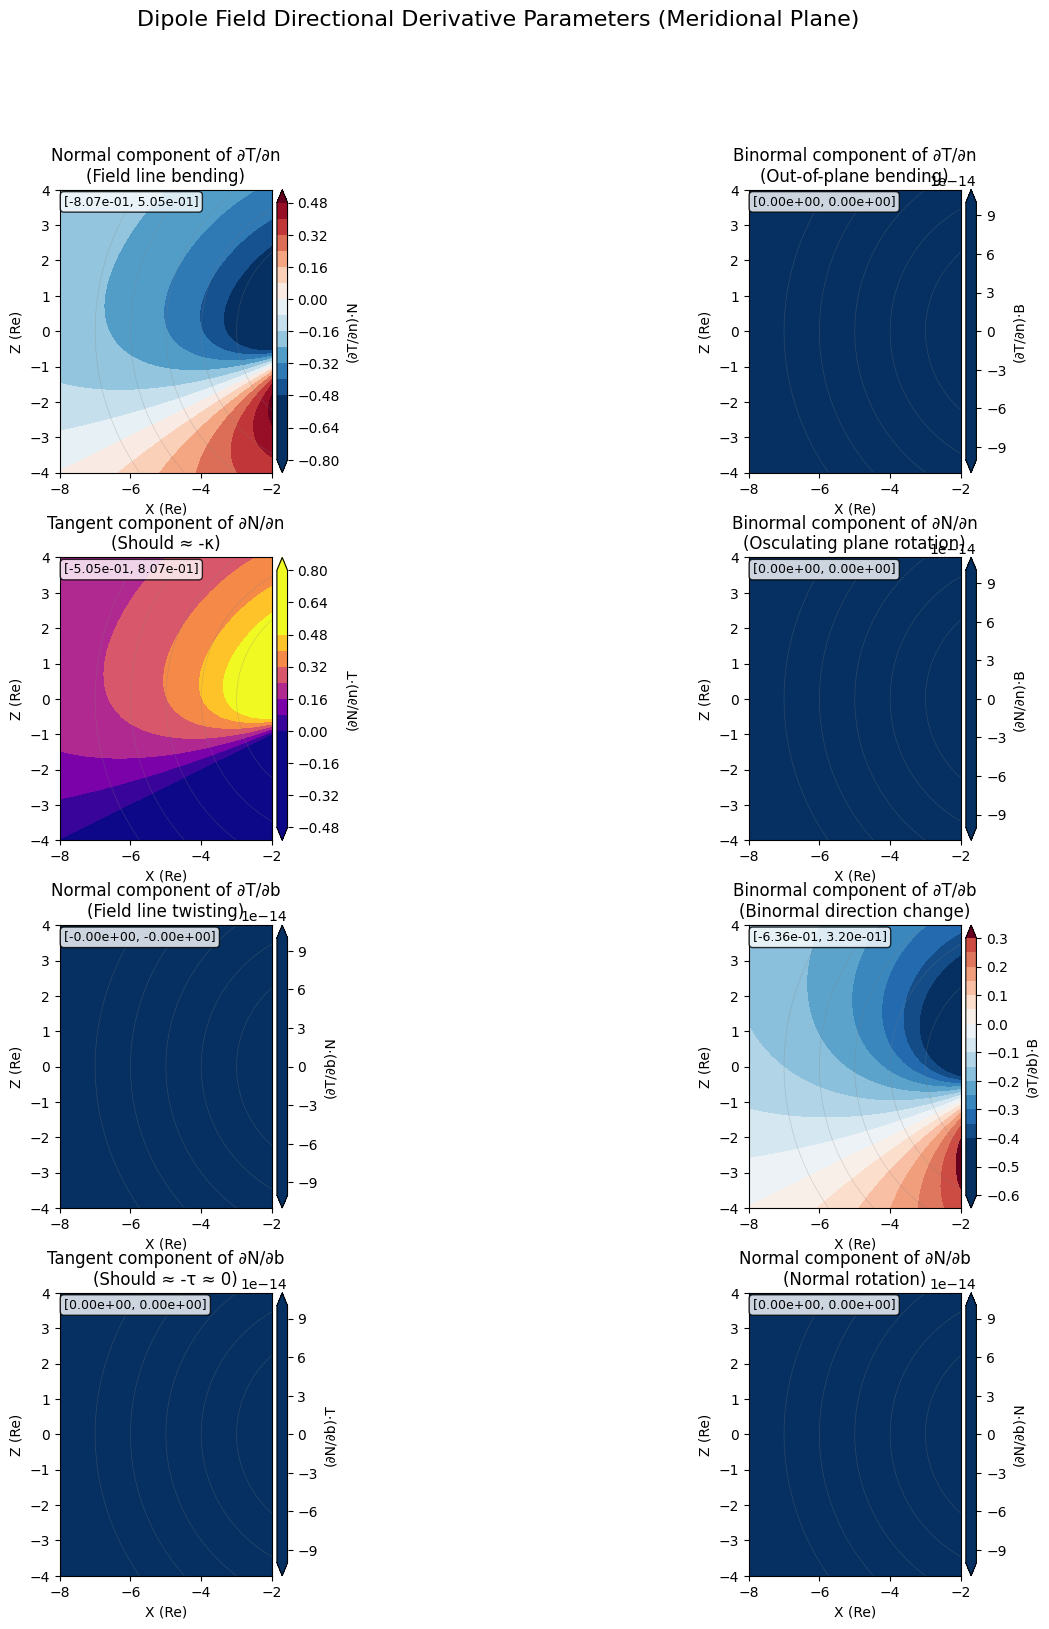

In [5]:
# Create figure with 8 subplots for the 8 parameters
fig = plt.figure(figsize=(16, 18))
gs = GridSpec(4, 2, figure=fig, hspace=0.3, wspace=0.25)

# Parameter names and expected behaviors
plot_info = [
    ('(∂T/∂n)·N', 'Normal component of ∂T/∂n\n(Field line bending)', 'RdBu_r'),
    ('(∂T/∂n)·B', 'Binormal component of ∂T/∂n\n(Out-of-plane bending)', 'RdBu_r'),
    ('(∂N/∂n)·T', 'Tangent component of ∂N/∂n\n(Should ≈ -κ)', 'plasma'),
    ('(∂N/∂n)·B', 'Binormal component of ∂N/∂n\n(Osculating plane rotation)', 'RdBu_r'),
    ('(∂T/∂b)·N', 'Normal component of ∂T/∂b\n(Field line twisting)', 'RdBu_r'),
    ('(∂T/∂b)·B', 'Binormal component of ∂T/∂b\n(Binormal direction change)', 'RdBu_r'),
    ('(∂N/∂b)·T', 'Tangent component of ∂N/∂b\n(Should ≈ -τ ≈ 0)', 'RdBu_r'),
    ('(∂N/∂b)·N', 'Normal component of ∂N/∂b\n(Normal rotation)', 'RdBu_r')
]

for idx, (param_name, title, cmap) in enumerate(plot_info):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    
    # Get data
    data = params[param_name]
    
    # Determine appropriate scale
    vmax = np.percentile(np.abs(data), 95)
    if vmax < 1e-10:
        vmax = np.max(np.abs(data))
    vmin = -vmax if 'RdBu' in cmap else 0
    
    # Plot
    im = ax.contourf(X_mer, Z_mer, data, levels=20, cmap=cmap, 
                     vmin=vmin, vmax=vmax, extend='both')
    
    # Add field lines
    ax.contour(X_mer, Z_mer, X_mer**2 + Z_mer**2, levels=[9, 16, 25, 36, 49], 
               colors='gray', alpha=0.3, linewidths=0.5)
    
    # Labels and formatting
    ax.set_xlabel('X (Re)')
    ax.set_ylabel('Z (Re)')
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    
    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label(param_name, fontsize=10)
    
    # Add text with range
    range_text = f"[{data.min():.2e}, {data.max():.2e}]"
    ax.text(0.02, 0.98, range_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Dipole Field Directional Derivative Parameters (Meridional Plane)', fontsize=16)
plt.tight_layout()
plt.show()

## Verify Key Relationships

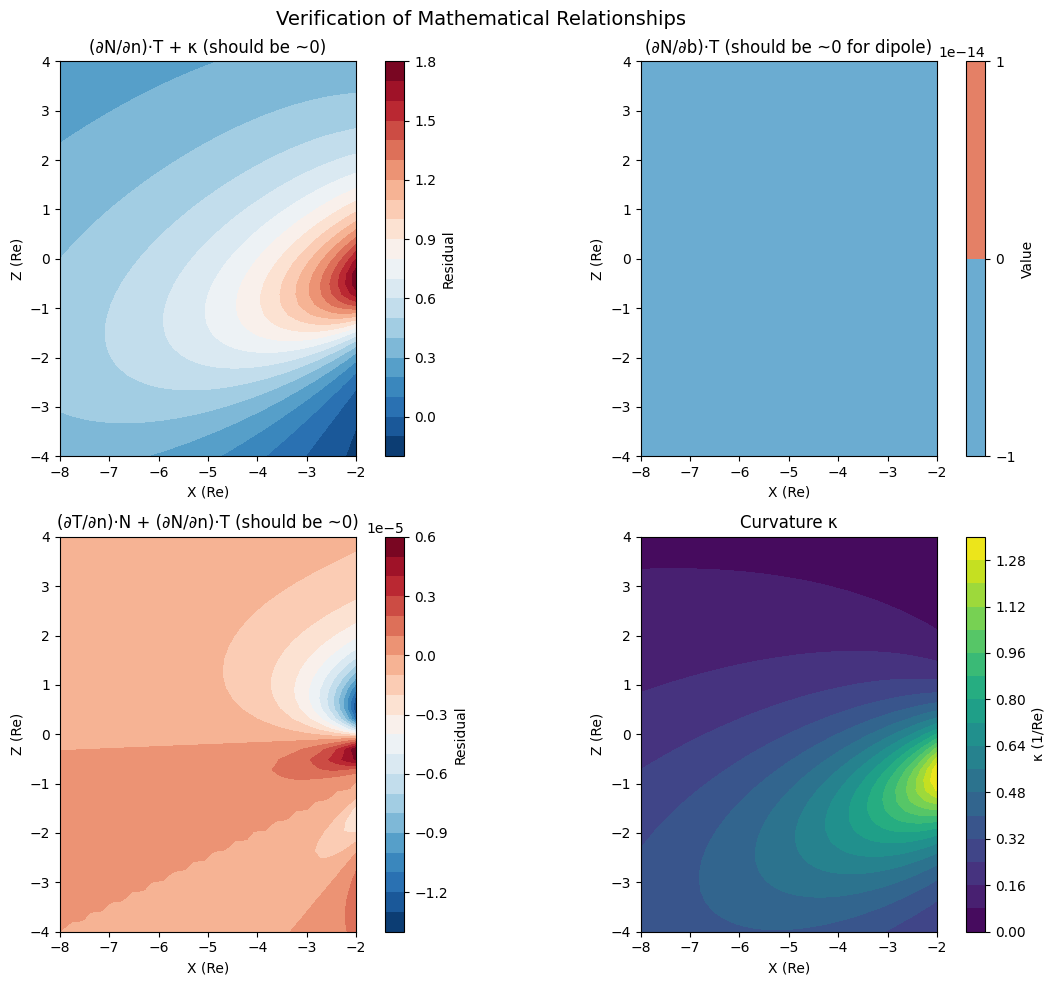

Quantitative Verification:
max|(∂N/∂n)·T + κ| = 1.760e+00
max|(∂N/∂b)·T| = 0.000e+00 (should be ~0)
max|(∂T/∂n)·N + (∂N/∂n)·T| = 1.301e-05

For comparison:
max|κ| = 1.358
max|τ| = 0.000e+00


In [6]:
# Verify expected relationships
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Check (∂N/∂n)·T ≈ -κ
ax = axes[0, 0]
diff1 = params['(∂N/∂n)·T'] + curvature_mer_grid
im1 = ax.contourf(X_mer, Z_mer, diff1, levels=20, cmap='RdBu_r')
ax.set_title('(∂N/∂n)·T + κ (should be ~0)')
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')
plt.colorbar(im1, ax=ax, label='Residual')

# 2. Check (∂N/∂b)·T ≈ -τ ≈ 0 for dipole
ax = axes[0, 1]
im2 = ax.contourf(X_mer, Z_mer, params['(∂N/∂b)·T'], levels=20, cmap='RdBu_r')
ax.set_title('(∂N/∂b)·T (should be ~0 for dipole)')
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')
plt.colorbar(im2, ax=ax, label='Value')

# 3. Antisymmetry: (∂T/∂n)·N + (∂N/∂n)·T = 0
ax = axes[1, 0]
antisym1 = params['(∂T/∂n)·N'] + params['(∂N/∂n)·T']
im3 = ax.contourf(X_mer, Z_mer, antisym1, levels=20, cmap='RdBu_r')
ax.set_title('(∂T/∂n)·N + (∂N/∂n)·T (should be ~0)')
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')
plt.colorbar(im3, ax=ax, label='Residual')

# 4. Plot curvature for reference
ax = axes[1, 1]
im4 = ax.contourf(X_mer, Z_mer, curvature_mer_grid, levels=20, cmap='viridis')
ax.set_title('Curvature κ')
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_aspect('equal')
plt.colorbar(im4, ax=ax, label='κ (1/Re)')

plt.suptitle('Verification of Mathematical Relationships', fontsize=14)
plt.tight_layout()
plt.show()

# Print quantitative verification
print("Quantitative Verification:")
print("=" * 50)
print(f"max|(∂N/∂n)·T + κ| = {np.max(np.abs(diff1)):.3e}")
print(f"max|(∂N/∂b)·T| = {np.max(np.abs(params['(∂N/∂b)·T'])):.3e} (should be ~0)")
print(f"max|(∂T/∂n)·N + (∂N/∂n)·T| = {np.max(np.abs(antisym1)):.3e}")
print(f"\nFor comparison:")
print(f"max|κ| = {np.max(np.abs(curvature_mer_grid)):.3f}")
print(f"max|τ| = {np.max(np.abs(torsion_mer_grid)):.3e}")

## Analyze Along a Single Field Line

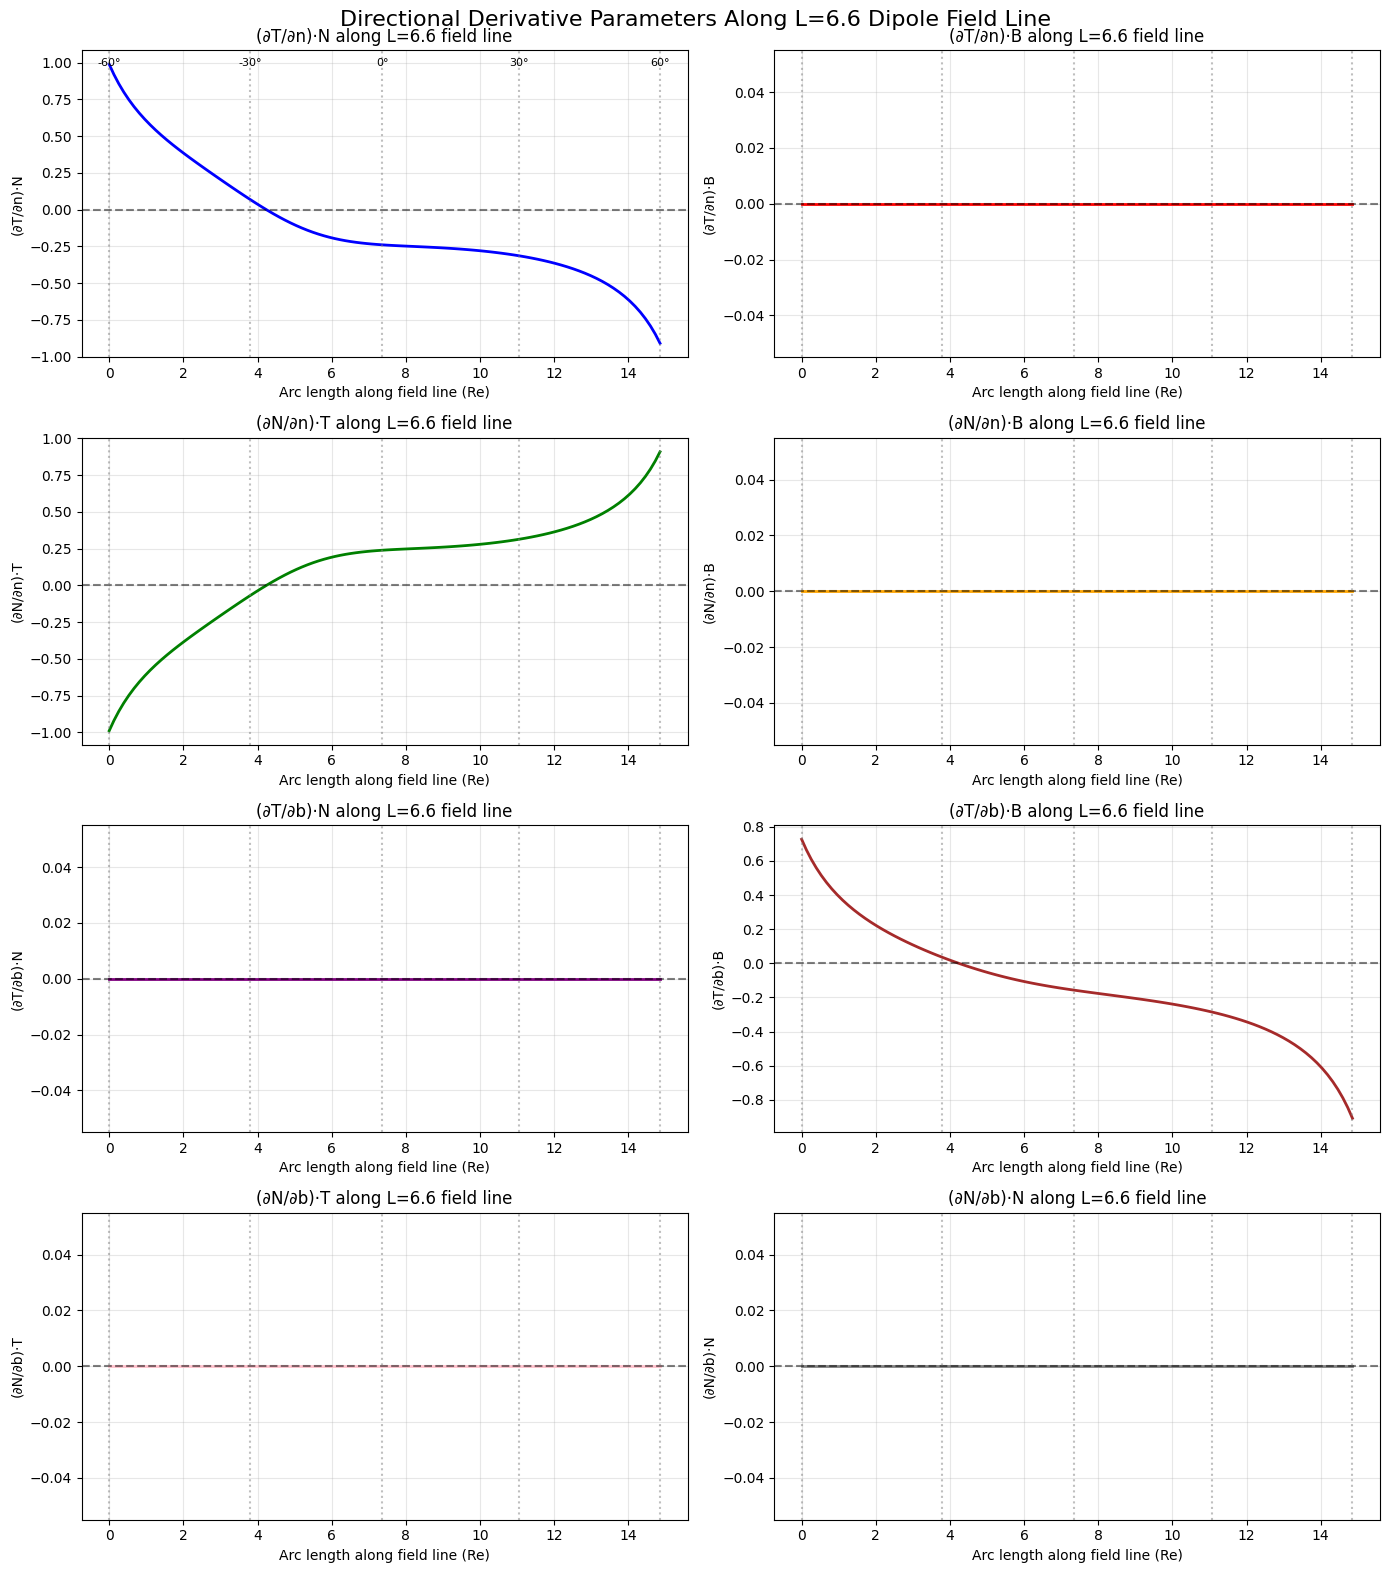

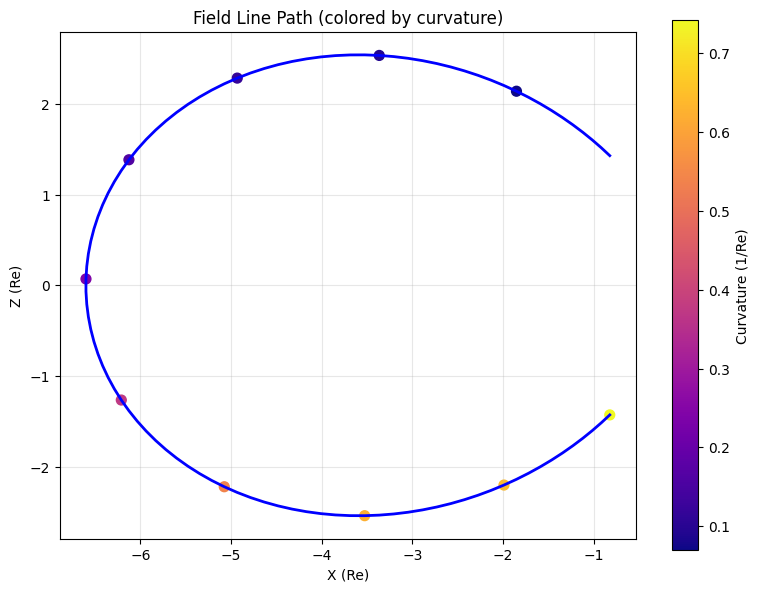

In [7]:
# Trace along a dipole field line
# For a dipole, field lines follow r = L*cos²(λ) where λ is magnetic latitude
L = 6.6  # L-shell
lambda_vals = np.linspace(-60, 60, 100) * np.pi/180  # Magnetic latitude in radians

# Convert to Cartesian coordinates
r = L * np.cos(lambda_vals)**2
x_line = -r * np.cos(lambda_vals)  # Negative for tailward
z_line = r * np.sin(lambda_vals)
y_line = np.zeros_like(x_line)

# Calculate all parameters along the field line
curv_line = field_line_curvature_vectorized(
    dipole_field_wrapper, None, ps, x_line, y_line, z_line
)

# Calculate derivatives
dT_dn_line = field_line_tangent_normal_derivative_vectorized(
    dipole_field_wrapper, None, ps, x_line, y_line, z_line
)
dN_dn_line = field_line_normal_normal_derivative_vectorized(
    dipole_field_wrapper, None, ps, x_line, y_line, z_line
)
dT_db_line = field_line_tangent_binormal_derivative_vectorized(
    dipole_field_wrapper, None, ps, x_line, y_line, z_line
)
dN_db_line = field_line_normal_binormal_derivative_vectorized(
    dipole_field_wrapper, None, ps, x_line, y_line, z_line
)

# Create comprehensive plot
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

# Arc length along field line (approximate)
ds = np.sqrt(np.diff(x_line)**2 + np.diff(y_line)**2 + np.diff(z_line)**2)
s = np.concatenate([[0], np.cumsum(ds)])

# Plot each parameter
plot_data = [
    (dT_dn_line[4], '(∂T/∂n)·N', 'blue'),
    (dT_dn_line[5], '(∂T/∂n)·B', 'red'),
    (dN_dn_line[3], '(∂N/∂n)·T', 'green'),
    (dN_dn_line[5], '(∂N/∂n)·B', 'orange'),
    (dT_db_line[4], '(∂T/∂b)·N', 'purple'),
    (dT_db_line[5], '(∂T/∂b)·B', 'brown'),
    (dN_db_line[3], '(∂N/∂b)·T', 'pink'),
    (dN_db_line[4], '(∂N/∂b)·N', 'gray')
]

for idx, (data, label, color) in enumerate(plot_data):
    ax = axes[idx // 2, idx % 2]
    ax.plot(s, data, color=color, linewidth=2)
    ax.set_xlabel('Arc length along field line (Re)')
    ax.set_ylabel(label)
    ax.set_title(f'{label} along L={L} field line')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Add latitude markers
    for lat in [-60, -30, 0, 30, 60]:
        idx_lat = np.argmin(np.abs(lambda_vals - lat*np.pi/180))
        ax.axvline(x=s[idx_lat], color='gray', linestyle=':', alpha=0.5)
        if idx == 0:  # Only label on first subplot
            ax.text(s[idx_lat], ax.get_ylim()[1]*0.9, f'{lat}°', 
                   ha='center', fontsize=8)

plt.suptitle(f'Directional Derivative Parameters Along L={L} Dipole Field Line', fontsize=16)
plt.tight_layout()
plt.show()

# Also plot the field line path
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_line, z_line, 'b-', linewidth=2, label=f'L={L} field line')
ax.scatter(x_line[::10], z_line[::10], c=curv_line[::10], cmap='plasma', s=50)
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_title('Field Line Path (colored by curvature)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Curvature (1/Re)')
plt.tight_layout()
plt.show()

## Compare with Analytical Dipole Properties

For a dipole field, we can calculate some properties analytically:
- Field lines are planar (τ = 0 in meridional planes)
- Curvature has a known form related to magnetic latitude

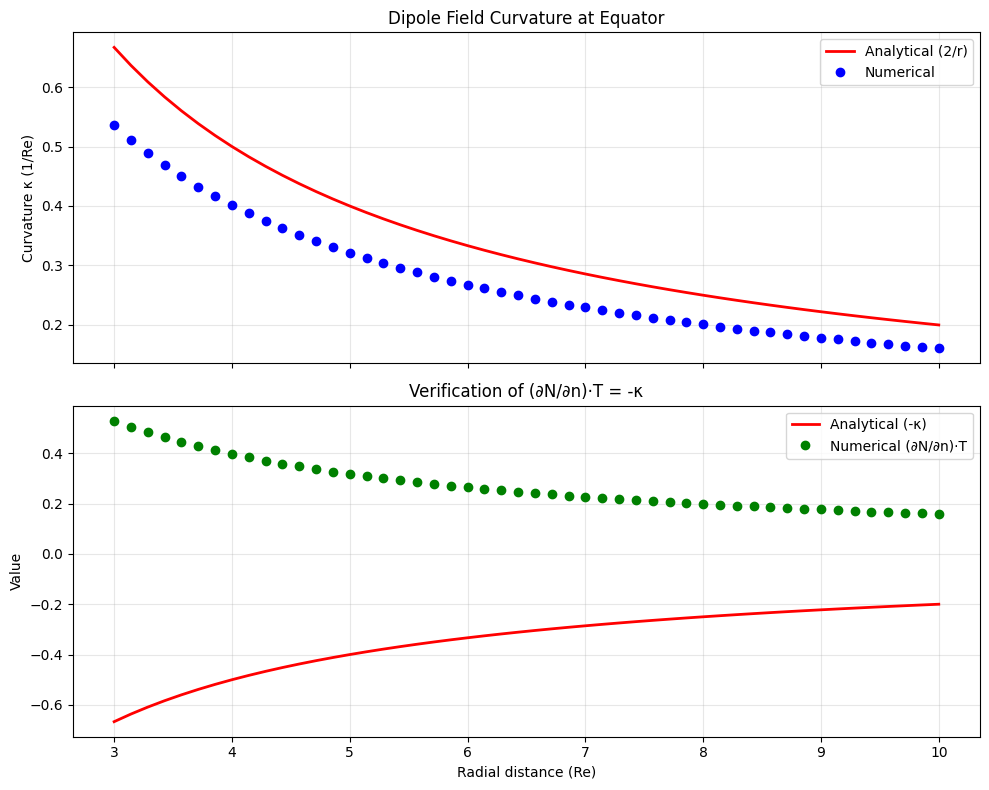

Analytical vs Numerical Comparison:
Maximum relative error in curvature: 19.69%
Mean relative error in curvature: 19.69%

Maximum error in (∂N/∂n)·T = -κ relation: 198.87%
Mean error in (∂N/∂n)·T = -κ relation: 198.87%


In [8]:
# Analytical comparison for dipole field
# Select points along the equator for simplicity
r_eq = np.linspace(3, 10, 50)
x_eq = -r_eq
y_eq = np.zeros_like(r_eq)
z_eq = np.zeros_like(r_eq)

# Calculate numerical values
curv_numerical = field_line_curvature_vectorized(
    dipole_field_wrapper, None, ps, x_eq, y_eq, z_eq
)

# For a dipole at the equator, curvature κ = 2/r
curv_analytical = 2.0 / r_eq

# Calculate derivatives
dN_dn_eq = field_line_normal_normal_derivative_vectorized(
    dipole_field_wrapper, None, ps, x_eq, y_eq, z_eq
)
dN_dn_t_eq = dN_dn_eq[3]

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Curvature comparison
ax = axes[0]
ax.plot(r_eq, curv_analytical, 'r-', linewidth=2, label='Analytical (2/r)')
ax.plot(r_eq, curv_numerical, 'bo', markersize=6, label='Numerical')
ax.set_ylabel('Curvature κ (1/Re)')
ax.set_title('Dipole Field Curvature at Equator')
ax.legend()
ax.grid(True, alpha=0.3)

# Check (∂N/∂n)·T = -κ
ax = axes[1]
ax.plot(r_eq, -curv_analytical, 'r-', linewidth=2, label='Analytical (-κ)')
ax.plot(r_eq, dN_dn_t_eq, 'go', markersize=6, label='Numerical (∂N/∂n)·T')
ax.set_xlabel('Radial distance (Re)')
ax.set_ylabel('Value')
ax.set_title('Verification of (∂N/∂n)·T = -κ')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
curv_error = np.abs(curv_numerical - curv_analytical) / curv_analytical
relation_error = np.abs(dN_dn_t_eq + curv_numerical) / curv_numerical

print("Analytical vs Numerical Comparison:")
print("=" * 50)
print(f"Maximum relative error in curvature: {np.max(curv_error)*100:.2f}%")
print(f"Mean relative error in curvature: {np.mean(curv_error)*100:.2f}%")
print(f"\nMaximum error in (∂N/∂n)·T = -κ relation: {np.max(relation_error)*100:.2f}%")
print(f"Mean error in (∂N/∂n)·T = -κ relation: {np.mean(relation_error)*100:.2f}%")

## Summary of Dipole Field Properties

The analysis reveals several key features of the dipole field:

1. **Planar field lines**: In meridional planes, the torsion is essentially zero, confirming that dipole field lines lie in planes.

2. **Curvature pattern**: Maximum curvature occurs near the Earth, decreasing with distance. The equatorial curvature follows κ = 2/r.

3. **Directional derivatives**:
   - **(∂T/∂n)·N**: Non-zero, represents how the field line bends
   - **(∂T/∂n)·B**: Near zero in meridional plane (no out-of-plane bending)
   - **(∂N/∂n)·T**: Equals -κ as expected from theory
   - **(∂N/∂b)·T**: Near zero (equals -τ ≈ 0 for planar field lines)

4. **Symmetries**: The dipole field's azimuthal symmetry is reflected in the patterns of the directional derivatives.

This analysis demonstrates that the directional derivative functions correctly capture the geometric properties of magnetic field lines, even for the idealized case of a pure dipole field.

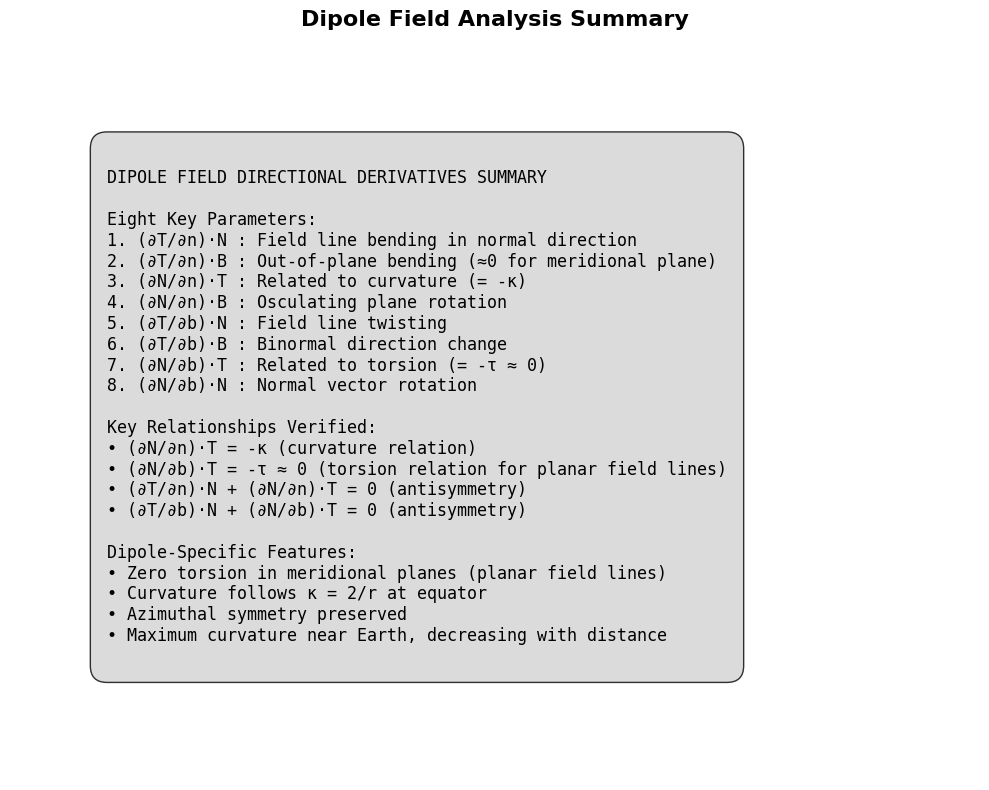

In [9]:
# Create a summary figure showing the key relationships
fig, ax = plt.subplots(figsize=(10, 8))

# Create text summary
summary_text = """
DIPOLE FIELD DIRECTIONAL DERIVATIVES SUMMARY

Eight Key Parameters:
1. (∂T/∂n)·N : Field line bending in normal direction
2. (∂T/∂n)·B : Out-of-plane bending (≈0 for meridional plane)
3. (∂N/∂n)·T : Related to curvature (= -κ)
4. (∂N/∂n)·B : Osculating plane rotation
5. (∂T/∂b)·N : Field line twisting
6. (∂T/∂b)·B : Binormal direction change
7. (∂N/∂b)·T : Related to torsion (= -τ ≈ 0)
8. (∂N/∂b)·N : Normal vector rotation

Key Relationships Verified:
• (∂N/∂n)·T = -κ (curvature relation)
• (∂N/∂b)·T = -τ ≈ 0 (torsion relation for planar field lines)
• (∂T/∂n)·N + (∂N/∂n)·T = 0 (antisymmetry)
• (∂T/∂b)·N + (∂N/∂b)·T = 0 (antisymmetry)

Dipole-Specific Features:
• Zero torsion in meridional planes (planar field lines)
• Curvature follows κ = 2/r at equator
• Azimuthal symmetry preserved
• Maximum curvature near Earth, decreasing with distance
"""

ax.text(0.1, 0.5, summary_text, transform=ax.transAxes, 
        fontsize=12, verticalalignment='center',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=1', facecolor='lightgray', alpha=0.8))
ax.axis('off')
ax.set_title('Dipole Field Analysis Summary', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()